# Rental crisis in Portugal — H1: long-term rent vs wages

**Hypothesis H1:** the **long-term rental** price in Portugal (median €/m² per month of new lease contracts) has grown faster than wages since 2017.

| Data | INE indicator | Used for |
|---|---|---|
| Long-term rental price, 2021 methodology (old regions) | `0009817` | rent 2017–2023 |
| Long-term rental price, 2021 methodology (new regions) | `0012598` | rent 2020–2024 |
| Long-term rental price, 2026 methodology | `0014696` | rent growth after 2024 (to 2Q 2026) |
| Average gross monthly earnings per employee | `0011132` | wages |
| Resident population by municipality | `0012918` | small vs large municipalities |

All data comes from INE (Statistics Portugal) via its **API**.

**Method in 3 steps**
1. One value per **calendar year** 2017–2025, plus the **latest 12 months (to June 2026 = 2Q 2026, the same latest period as in the rest of the project)**. Rent = median of the contracts signed in those 12 months, wage = average of the four quarters.
2. Both are turned into an **index (2017 = 100)**, so we can compare their growth.
3. The same comparison for **small vs large municipalities** (≤ / > 50,000 residents, as in the rest of the project).

*€/m² is the **monthly long-term rent per square metre** from signed contracts, not a tourist price.*

**The story in 4 charts**
1. Rent vs wages since 2017 (index)
2. The same in euros: an 80 m² flat vs the average salary
3. How much of an average salary that flat costs
4. Small vs large municipalities

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

# Folders (this notebook lives in the repo root, next to the data and figures folders)
RAW_FOLDER = Path("data/raw")
CLEAN_FOLDER = Path("data/clean")
FIGURES_FOLDER = Path("figures")
for folder in [RAW_FOLDER, CLEAN_FOLDER, FIGURES_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

INE_URL = "https://www.ine.pt/ine/json_indicador/pindica.jsp"

START_YEAR = 2017
LAST_FULL_YEAR = 2025
LATEST_RENT_PERIOD = "2nd Quarter 2026"   # latest data (2Q 2026), the same as in the rest of the project
LATEST_WAGE_PERIOD = "June 2026"          # wage quarter ending in June 2026
LATEST_LABEL = "Jun 2026"                 # label for "the 12 months to June 2026"
FLAT_SIZE_M2 = 80                         # example flat, the same as in the rest of the project

## 2. Data collection (INE API)

`get_ine()` reads the saved file if it exists; otherwise it calls the INE API once and saves the answer in `data/raw/`.

* `Dim1 = "T"` asks for **all periods**.
* Population: most recent year, totals only (`Dim3 = "T"`, `Dim4 = "T"`), exactly as in the rest of the project.
* INE's server can be slow; if a request times out, just run the cell again.

In [2]:
def get_ine(code, params, file_name):
    """Read the saved file if it exists, otherwise call the INE API and save the answer."""
    path = RAW_FOLDER / file_name
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))

    print(f"Calling the INE API for indicator {code} ...")
    response = requests.get(INE_URL, params={"op": "2", "varcd": code, "lang": "EN", **params}, timeout=180)
    response.raise_for_status()
    data = response.json()
    path.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
    return data


def to_table(data):
    """INE returns {period: [records]}. Turn it into one row per period and place."""
    rows = []
    for period, records in data[0]["Dados"].items():
        for record in records:
            rows.append({"period": period, **record})
    return pd.DataFrame(rows)


ALL_PERIODS = {"Dim1": "T"}

rent_old_raw = to_table(get_ine("0009817", ALL_PERIODS, "ine_0009817_all.json"))
rent_old2_raw = to_table(get_ine("0012598", ALL_PERIODS, "ine_0012598_all.json"))
rent_new_raw = to_table(get_ine("0014696", ALL_PERIODS, "ine_0014696_all.json"))
wages_raw = to_table(get_ine("0011132", ALL_PERIODS, "ine_0011132_all.json"))
population_raw = to_table(get_ine("0012918", {"Dim3": "T", "Dim4": "T"}, "ine_0012918_Dim3T_Dim4T.json"))

## 3. First look at the data

* **Rent:** one row per place (country, regions, municipalities, parishes) and period. The value is the **median of the last 12 months**.
* The length of `geocod` tells us the level: `PT` = Portugal, 7 characters = municipality, 9 = parish.
* **Wages:** monthly labels, but each value is the average of the **quarter** ending in that month ("March 2026" = 1st quarter 2026).
* `valor` = the number (stored as text), `sinal_conv` = marks values INE does not publish (too few contracts).

In [3]:
for name, df in [("rent old", rent_old_raw), ("rent old, new regions", rent_old2_raw),
                 ("rent new", rent_new_raw), ("wages", wages_raw), ("population", population_raw)]:
    print(f"{name:22} rows: {len(df):6}   periods: {df['period'].nunique():4}   "
          f"first: {df['period'].iloc[0]:22}   last: {df['period'].iloc[-1]}")

rent old               rows:   8255   periods:   13   first: 2nd Semi-annual 2017     last: 2nd Semi-annual 2023
rent old, new regions  rows:   5742   periods:    9   first: 2nd Semi-annual 2020     last: 2nd Semi-annual 2024
rent new               rows:  16588   periods:   26   first: 1st Quarter 2020         last: 2nd Quarter 2026
wages                  rows:   2960   periods:  148   first: March 2014               last: June 2026
population             rows:    347   periods:    1   first: 2025                     last: 2025


In [4]:
# Rent in Portugal as a whole: the first rows of the old series
rent_old_raw[rent_old_raw["geocod"] == "PT"][["period", "geocod", "geodsg", "valor"]].head()

,period,geocod,geodsg,valor
255,2nd Semi-annual 2017,PT,Portugal,4.39
885,1st Semi-annual 2018,PT,Portugal,4.58
1519,2nd Semi-annual 2018,PT,Portugal,4.8
2143,1st Semi-annual 2019,PT,Portugal,5
2768,2nd Semi-annual 2019,PT,Portugal,5.32


## 4. Cleaning

| Problem | Technique |
|---|---|
| Rent: several values per year (half-years, quarters) | keep the **12 months to December** (= one calendar year) and the latest 12 months (to June 2026) |
| Period written as text ("2nd Semi-annual 2017") | string methods: `.str.startswith()`, `.str[-4:]` |
| Numbers stored as text | `pd.to_numeric()` |
| Wages: many components and sectors | filter the totals (`dim_3 == "T"`, `dim_4 == "T"`) |
| Wages: quarterly values | yearly average with `groupby()`; latest 12 months = average of the last 4 quarters |
| Country, regions, municipalities and parishes mixed | filter on the length of `geocod` |
| Municipality codes differ between old and new regions | use the **last 4 digits** of `geocod` (they never change) |
| Places without a published value | drop missing values and report how many |

In [5]:
def clean_rent(df):
    """One row per place and year: the median rent of the 12 months to December (= that calendar year).
    Year 2026 = the latest period: the 12 months to June 2026."""
    is_december = df["period"].str.startswith(("2nd Semi-annual", "4th Quarter"))
    df = df[is_december | (df["period"] == LATEST_RENT_PERIOD)].copy()
    df["year"] = df["period"].str[-4:].astype(int)
    df["rent"] = pd.to_numeric(df["valor"], errors="coerce")
    df["code"] = df["geocod"].str[-4:]                    # municipality code, the same in old and new regions
    return df[["geocod", "code", "geodsg", "year", "rent"]]


QUARTER_MONTHS = {"March": 3, "June": 6, "September": 9, "December": 12}


def clean_wages(df):
    """Average gross monthly earnings (total, all activities): one row per quarter, in time order."""
    df = df[(df["dim_3"].astype(str) == "T") & (df["dim_4"].astype(str) == "T")].copy()
    df["month_name"] = df["period"].str.split().str[0]
    df = df[df["month_name"].isin(QUARTER_MONTHS)].copy()      # keep the 4 quarter-end months
    df["year"] = df["period"].str[-4:].astype(int)
    df["month"] = df["month_name"].map(QUARTER_MONTHS)
    df["wage"] = pd.to_numeric(df["valor"], errors="coerce")
    return df.sort_values(["year", "month"])[["period", "year", "wage"]]


rent_old = clean_rent(rent_old_raw)
rent_old2 = clean_rent(rent_old2_raw)
rent_new = clean_rent(rent_new_raw)
wages_quarterly = clean_wages(wages_raw)

# One value per calendar year (only years with all 4 quarters) ...
quarters_per_year = wages_quarterly.groupby("year")["wage"].count()
full_years = quarters_per_year[quarters_per_year == 4].index
wages = wages_quarterly[wages_quarterly["year"].isin(full_years)].groupby("year")["wage"].mean()

# ... and the latest 12 months = the average of the last 4 quarters
print("Latest wage quarter:", wages_quarterly["period"].iloc[-1], "(expected:", LATEST_WAGE_PERIOD + ")")
wage_latest = wages_quarterly["wage"].tail(4).mean()
print(f"Average wage, 12 months to June 2026: {wage_latest:,.0f} €")
wages.round(0).tail()

Latest wage quarter: June 2026 (expected: June 2026)
Average wage, 12 months to June 2026: 1,738 €


year
2021    1360.0
2022    1410.0
2023    1506.0
2024    1603.0
2025    1695.0
Name: wage, dtype: float64

### Joining the rent series (chain-linking)

INE changed its rent method in 2026. The new series has **different levels** (end of 2020: 5.79 vs 5.61 €/m²), so we cannot simply glue it to the old one. We therefore:

1. use the **old method for 2017–2024** (its two versions are identical for Portugal, we check that below),
2. add **2025** and the **12 months to June 2026** by applying the new method's **growth since 2024** to the old 2024 value:

`rent 2025 = rent 2024 (old) × new 2025 / new 2024`  ·  `rent Jun 2026 = rent 2024 (old) × new Jun 2026 / new 2024`

In [6]:
def national(df):
    """Portugal as a whole: one rent value per year."""
    return df[df["geocod"] == "PT"].set_index("year")["rent"]


old_pt = national(rent_old)
old2_pt = national(rent_old2)
new_pt = national(rent_new)

# Check: the two versions of the old method give the same numbers for Portugal
both_years = old_pt.index.intersection(old2_pt.index)
print("Largest difference between the two old versions:", (old_pt[both_years] - old2_pt[both_years]).abs().max(), "€/m²")

# Old method 2017–2024, then 2025 and the 12 months to June 2026 from the growth of the new method
rent_pt = pd.concat([old_pt, old2_pt[old2_pt.index > old_pt.index.max()]])
rent_pt[2025] = rent_pt[2024] * new_pt[2025] / new_pt[2024]
rent_latest = rent_pt[2024] * new_pt[2026] / new_pt[2024]          # new_pt[2026] = 12 months to June 2026

print(f"New method, growth 2024 → Jun 2026: {(new_pt[2026] / new_pt[2024] - 1) * 100:.1f}%")
print(f"Rent, 12 months to June 2026: {rent_latest:.2f} €/m²")
rent_pt.round(2)

Largest difference between the two old versions: 0.0 €/m²
New method, growth 2024 → Jun 2026: 15.2%
Rent, 12 months to June 2026: 9.18 €/m²


year
2017    4.39
2018    4.80
2019    5.32
2020    5.61
2021    6.04
2022    6.52
2023    7.21
2024    7.97
2025    8.74
Name: rent, dtype: float64

### Main cleaning function

`build_h1_table()` puts all steps above together: one row per year 2017–2025, plus one row for the latest 12 months (`Jun 2026`).

In [7]:
def build_h1_table():
    """Clean table for H1: long-term rent (€/m²) and average gross monthly wage (€),
    one row per year 2017–2025 plus the latest 12 months (to June 2026)."""
    table = pd.DataFrame({"rent": rent_pt, "wage": wages}).loc[START_YEAR:LAST_FULL_YEAR]
    table.index = table.index.astype(str)                     # "2017", "2018", ...
    table.loc[LATEST_LABEL] = [rent_latest, wage_latest]
    table.index.name = "period"
    return table


h1 = build_h1_table()

# Validation against figures published by INE
print("Rent 2017:", h1.loc["2017", "rent"], "€/m²   (INE: 4.39)")
print("Rent 2024:", h1.loc["2024", "rent"], "€/m²   (INE: 7.97)")
print("Wage 2025:", round(h1.loc["2025", "wage"]), "€      (INE: 1,694 – a few euros difference is normal)")
h1.round(2)

Rent 2017: 4.39 €/m²   (INE: 4.39)
Rent 2024: 7.97 €/m²   (INE: 7.97)
Wage 2025: 1695 €      (INE: 1,694 – a few euros difference is normal)


,rent,wage
period,,
2017,4.39,1215.00
2018,4.80,1240.25
2019,5.32,1275.75
2020,5.61,1315.50
2021,6.04,1360.25
2022,6.52,1410.25
2023,7.21,1505.50
2024,7.97,1603.00
2025,8.74,1695.00


## 5. Analysis

* **Index:** each series divided by its 2017 value × 100 → both start at 100, so growth is directly comparable.
* **In euros:** rent of an 80 m² flat = rent per m² × 80.
* **Affordability:** that rent as a share of the average gross monthly wage.

In [8]:
h1["rent_index"] = h1["rent"] / h1["rent"].iloc[0] * 100
h1["wage_index"] = h1["wage"] / h1["wage"].iloc[0] * 100
h1["rent_80m2"] = h1["rent"] * FLAT_SIZE_M2
h1["rent_share_of_wage"] = h1["rent_80m2"] / h1["wage"] * 100
h1.to_csv(CLEAN_FOLDER / "h1_clean.csv")

first, last = h1.index[0], h1.index[-1]                      # "2017" and "Jun 2026"
rent_growth = h1.loc[last, "rent_index"] - 100
wage_growth = h1.loc[last, "wage_index"] - 100

print(f"{first} → {last} (12 months to June 2026)")
print(f"  Long-term rent:  +{rent_growth:.1f}%")
print(f"  Wages:           +{wage_growth:.1f}%")
print(f"  Gap:             {rent_growth - wage_growth:.1f} percentage points")
print(f"  80 m² flat:      {h1.loc[first, 'rent_80m2']:.0f} € → {h1.loc[last, 'rent_80m2']:.0f} € a month")
print(f"  Share of salary: {h1.loc[first, 'rent_share_of_wage']:.0f}% → {h1.loc[last, 'rent_share_of_wage']:.0f}%")
h1.round(1)

2017 → Jun 2026 (12 months to June 2026)
  Long-term rent:  +109.2%
  Wages:           +43.0%
  Gap:             66.2 percentage points
  80 m² flat:      351 € → 735 € a month
  Share of salary: 29% → 42%


,rent,wage,rent_index,wage_index,rent_80m2,rent_share_of_wage
period,,,,,,
2017,4.4,1215.0,100.0,100.0,351.2,28.9
2018,4.8,1240.2,109.3,102.1,384.0,31.0
2019,5.3,1275.8,121.2,105.0,425.6,33.4
2020,5.6,1315.5,127.8,108.3,448.8,34.1
2021,6.0,1360.2,137.6,112.0,483.2,35.5
2022,6.5,1410.2,148.5,116.1,521.6,37.0
2023,7.2,1505.5,164.2,123.9,576.8,38.3
2024,8.0,1603.0,181.5,131.9,637.6,39.8
2025,8.7,1695.0,199.1,139.5,699.3,41.3


## 6. Small vs large municipalities

Is this only a big-city problem? We repeat the rent calculation for every **mainland municipality** and compare the two groups with the wage growth (wages exist only for Portugal as a whole).

* **Small:** up to 50,000 residents · **Large:** more than 50,000 residents (same definition as in the rest of the project)
* Same steps as above: 2017 and 2024 from the old method, June 2026 = 2024 × growth of the new method.
* Group result = the **median** municipality (each municipality counts once).

In [9]:
def mainland_municipalities(df):
    """Municipalities have a 7-character geocod; mainland Portugal codes start with '1'."""
    return df[(df["geocod"].str.len() == 7) & (df["geocod"].str.startswith("1"))]


def rent_in(df, year, column):
    """Rent of every mainland municipality in one year, as a column named `column`."""
    df = mainland_municipalities(df)
    return df[df["year"] == year].set_index("code")["rent"].rename(column)


# Population: totals, most recent year
population = mainland_municipalities(population_raw).copy()
population["code"] = population["geocod"].str[-4:]
population["population"] = pd.to_numeric(population["valor"], errors="coerce")
population = population.set_index("code")[["geodsg", "population"]].rename(columns={"geodsg": "municipality"})

municipalities = pd.concat([population,
                            rent_in(rent_old, START_YEAR, "rent_2017"),
                            rent_in(rent_old2, 2024, "rent_2024"),
                            rent_in(rent_new, 2024, "new_2024"),
                            rent_in(rent_new, 2026, "new_jun_2026")], axis=1)    # 2026 = 12 months to June 2026

municipalities["rent_jun_2026"] = (municipalities["rent_2024"] * municipalities["new_jun_2026"]
                                   / municipalities["new_2024"])
municipalities["rent_growth"] = (municipalities["rent_jun_2026"] / municipalities["rent_2017"] - 1) * 100
municipalities["size_group"] = pd.cut(municipalities["population"], bins=[0, 50_000, float("inf")],
                                      labels=["Small", "Large"])

print("Mainland municipalities:", len(municipalities), "(Portugal has 278)")
print("Municipalities per group:")
print(municipalities["size_group"].value_counts().sort_index().to_string())

Mainland municipalities: 278 (Portugal has 278)
Municipalities per group:
size_group
Small    216
Large     62


In [10]:
# Keep only municipalities with a rent value in every year we need
complete = municipalities.dropna(subset=["rent_growth", "size_group"])
print("With a complete rent value:", len(complete), "| dropped (too few contracts):",
      len(municipalities) - len(complete))

by_size = complete.groupby("size_group", observed=True).agg(
    municipalities=("rent_growth", "size"),
    rent_2017=("rent_2017", "median"),
    rent_jun_2026=("rent_jun_2026", "median"),
    rent_growth=("rent_growth", "median"),
)
by_size["rent_80m2_jun_2026"] = by_size["rent_jun_2026"] * FLAT_SIZE_M2
by_size["gap_vs_wages"] = by_size["rent_growth"] - wage_growth
complete.to_csv(CLEAN_FOLDER / "h1_municipalities_clean.csv")
by_size.round(1)

With a complete rent value: 186 | dropped (too few contracts): 92


,municipalities,rent_2017,rent_jun_2026,rent_growth,rent_80m2_jun_2026,gap_vs_wages
size_group,,,,,,
Small,124,2.9,5.6,93.1,451.8,50.1
Large,62,4.0,8.7,103.7,697.3,60.7


## 7. Visualisation

Same chart style as the rest of the project: white background, one blue accent, grey text, values written on the chart.

In [11]:
ACCENT = "#1c5cab"        # dark blue  = long-term rent
LIGHT_BLUE = "#86b6ef"    # light blue = wages / comparison
INK = "#0b0b0b"
GREY_TEXT = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": GRID, "axes.labelcolor": GREY_TEXT,
    "xtick.color": GREY_TEXT, "ytick.color": MUTED, "xtick.labelsize": 11, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})


def add_titles(fig, title, subtitle):
    """Bold headline that states the finding + grey subtitle that says what is measured."""
    fig.suptitle(title, x=0.02, y=0.98, ha="left", fontsize=15, fontweight="bold", color=INK)
    fig.text(0.02, 0.905, subtitle, ha="left", fontsize=11, color=GREY_TEXT)


def add_source(fig, text):
    """Small grey note at the bottom left."""
    fig.text(0.02, 0.015, text, ha="left", fontsize=8.5, color=MUTED)


def clean_bar_axes(ax):
    """Bar charts: values are written on the bars, so we hide the y axis."""
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="x", length=0, pad=8)
    ax.margins(y=0.15)


def clean_line_axes(ax):
    """Line charts: thin horizontal gridlines, no left border."""
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(length=0)


def save_chart(fig, file_name):
    """Leave room for titles and source, save for the slides, then show."""
    fig.tight_layout(rect=(0, 0.05, 1, 0.87))
    fig.savefig(FIGURES_FOLDER / file_name, dpi=200)
    plt.show()


SOURCE = ("Jun 2026 = the 12 months to June 2026.   2025 and Jun 2026: rent extended with the growth of INE's new method.   "
          "Source: INE.")

### Chart 1 – Rent vs wages since 2017 (index)

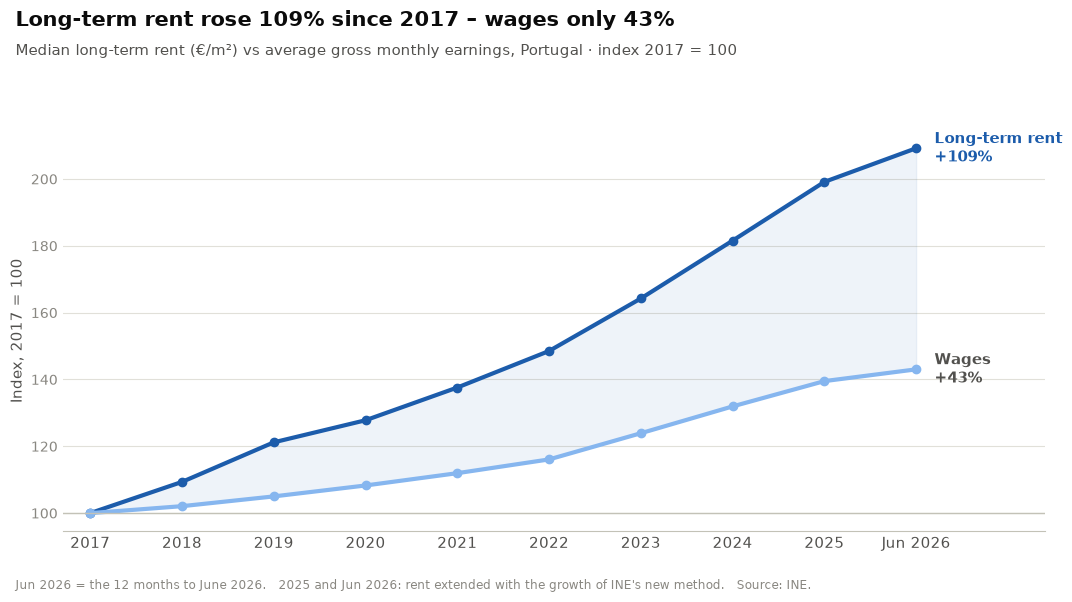

In [12]:
x = range(len(h1))                     # one position per period: 2017 ... 2025, Jun 2026
end = len(h1) - 1

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, h1["rent_index"], color=ACCENT, linewidth=3, marker="o")
ax.plot(x, h1["wage_index"], color=LIGHT_BLUE, linewidth=3, marker="o")
ax.fill_between(x, h1["wage_index"], h1["rent_index"], color=ACCENT, alpha=0.07)
ax.axhline(100, color="#c3c2b7", linewidth=1)

# Labels at the end of the lines instead of a legend
ax.text(end + 0.2, h1.loc[last, "rent_index"], f"Long-term rent\n+{rent_growth:.0f}%",
        color=ACCENT, fontweight="bold", va="center")
ax.text(end + 0.2, h1.loc[last, "wage_index"], f"Wages\n+{wage_growth:.0f}%",
        color=GREY_TEXT, fontweight="bold", va="center")

ax.set_xticks(x, h1.index)
ax.set_xlim(-0.3, end + 1.4)
ax.set_ylabel(f"Index, {first} = 100")
clean_line_axes(ax)
add_titles(fig, f"Long-term rent rose {rent_growth:.0f}% since {first} – wages only {wage_growth:.0f}%",
           f"Median long-term rent (€/m²) vs average gross monthly earnings, Portugal · index {first} = 100")
add_source(fig, SOURCE)
save_chart(fig, "h1_1_rent_vs_wages.png")

### Chart 2 – The same in euros: an 80 m² flat vs the average salary

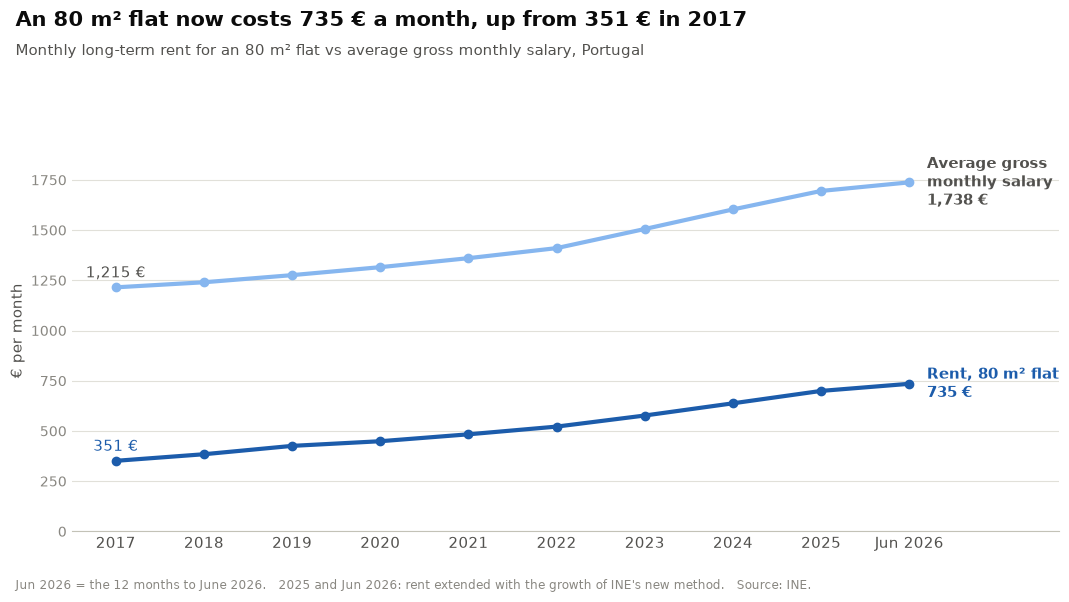

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, h1["wage"], color=LIGHT_BLUE, linewidth=3, marker="o")
ax.plot(x, h1["rent_80m2"], color=ACCENT, linewidth=3, marker="o")

for column, color, name in [("wage", GREY_TEXT, "Average gross\nmonthly salary"),
                            ("rent_80m2", ACCENT, f"Rent, {FLAT_SIZE_M2} m² flat")]:
    ax.text(0, h1.loc[first, column] + 50, f"{h1.loc[first, column]:,.0f} €", ha="center", color=color)
    ax.text(end + 0.2, h1.loc[last, column], f"{name}\n{h1.loc[last, column]:,.0f} €",
            va="center", color=color, fontweight="bold")

ax.set_xticks(x, h1.index)
ax.set_xlim(-0.5, end + 1.7)
ax.set_ylim(0, h1["wage"].max() * 1.15)                 # euro amounts: start the axis at zero
ax.set_ylabel("€ per month")
clean_line_axes(ax)
add_titles(fig, f"An {FLAT_SIZE_M2} m² flat now costs {h1.loc[last, 'rent_80m2']:,.0f} € a month, "
                f"up from {h1.loc[first, 'rent_80m2']:,.0f} € in {first}",
           f"Monthly long-term rent for an {FLAT_SIZE_M2} m² flat vs average gross monthly salary, Portugal")
add_source(fig, SOURCE)
save_chart(fig, "h1_2_rent_and_wages_in_euros.png")

### Chart 3 – How much of an average salary that flat costs

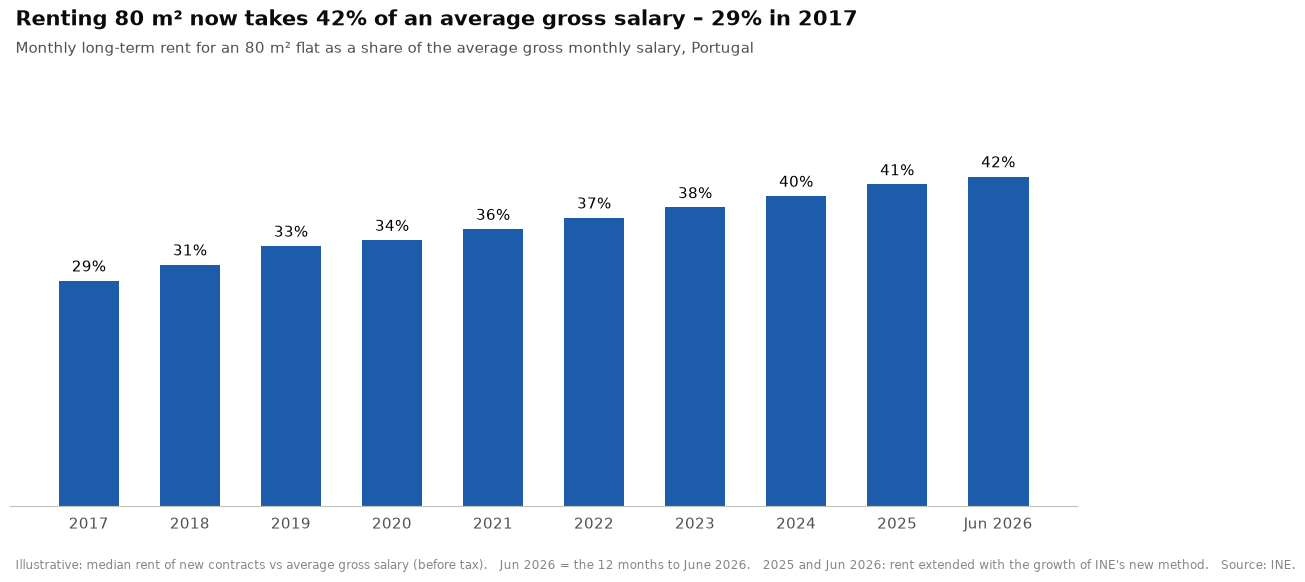

In [14]:
fig, ax = plt.subplots(figsize=(11, 5.8))
bars = ax.bar(h1.index, h1["rent_share_of_wage"], color=ACCENT, width=0.6)
ax.bar_label(bars, labels=[f"{value:.0f}%" for value in h1["rent_share_of_wage"]], padding=4, fontsize=11)
clean_bar_axes(ax)
add_titles(fig, f"Renting {FLAT_SIZE_M2} m² now takes {h1.loc[last, 'rent_share_of_wage']:.0f}% "
                f"of an average gross salary – {h1.loc[first, 'rent_share_of_wage']:.0f}% in {first}",
           f"Monthly long-term rent for an {FLAT_SIZE_M2} m² flat as a share of the average gross monthly salary, Portugal")
add_source(fig, "Illustrative: median rent of new contracts vs average gross salary (before tax).   " + SOURCE)
save_chart(fig, "h1_3_rent_share_of_salary.png")

### Chart 4 – Small vs large municipalities

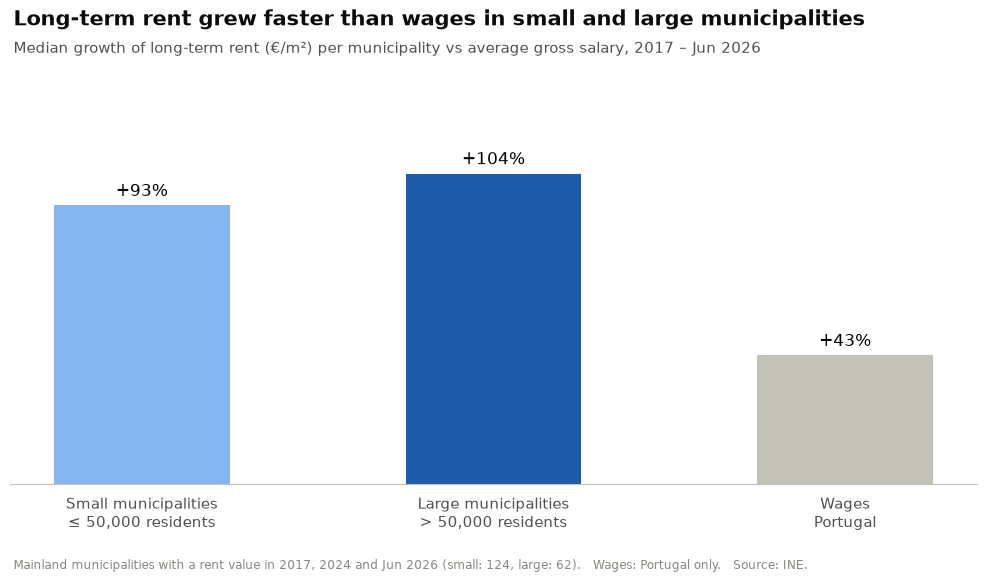

In [15]:
labels = ["Small municipalities\n≤ 50,000 residents", "Large municipalities\n> 50,000 residents", "Wages\nPortugal"]
values = [by_size.loc["Small", "rent_growth"], by_size.loc["Large", "rent_growth"], wage_growth]

fig, ax = plt.subplots(figsize=(10, 5.8))
bars = ax.bar(labels, values, color=[LIGHT_BLUE, ACCENT, "#c3c2b7"], width=0.5)
ax.bar_label(bars, labels=[f"+{value:.0f}%" for value in values], padding=4, fontsize=12)
clean_bar_axes(ax)
add_titles(fig, "Long-term rent grew faster than wages in small and large municipalities"
                if min(values[:2]) > wage_growth else "Rent vs wages in small and large municipalities",
           f"Median growth of long-term rent (€/m²) per municipality vs average gross salary, {first} – {last}")
add_source(fig, f"Mainland municipalities with a rent value in {first}, 2024 and {last} "
                f"(small: {by_size.loc['Small', 'municipalities']}, large: {by_size.loc['Large', 'municipalities']}).   "
                "Wages: Portugal only.   Source: INE.")
save_chart(fig, "h1_4_small_vs_large_municipalities.png")

## 8. Conclusion

*Numbers from our run on 29 September 2026 (latest data: 2Q 2026, the same as in the rest of the project).*

**H1 is supported.** Between 2017 and the 12 months to June 2026, the median long-term rent of new lease contracts in Portugal rose by **109%** (4.39 → 9.18 €/m²), while the average gross monthly salary rose by **43%** (1,215 → 1,738 €). Rent grew about **2.5 times as fast** as wages (Chart 1).

**In euros (Chart 2):** an 80 m² flat went from ≈ **351 €** to ≈ **735 €** a month. In euros the salary rose by more (+523 € vs +383 €), but from a much higher starting point.

**Affordability (Chart 3):** that flat took **29%** of an average gross salary in 2017 and **42%** in the 12 months to June 2026.

**Not only a big-city problem (Chart 4):** in the median small municipality (≤ 50,000 residents) long-term rent rose by **93%**, in the median large one by **104%**, both far more than wages (**+43%**). An 80 m² flat now costs ≈ **452 €** a month in the median small municipality and ≈ **697 €** in the median large one.

**Method check:** from 2017 to 2024 we use only INE's old method (rent +82% vs wages +32%), so the result does not depend on joining the two methods.

### Limitations
* Rent is the **median of new contracts**; wages are the **average of all jobs**. H1 describes people signing a new lease, not all tenants.
* Wages exist only for Portugal as a whole, so small and large municipalities are compared with the national wage.
* Rent for 2025 and the 12 months to June 2026 uses the growth of INE's new method.
* The national rent is the median of all contracts, not an average of municipalities, so it can differ from the group results in Chart 4.
* 92 small municipalities have no rent value for 2017 (too few contracts), so the small group mainly covers the larger small towns (124 of 216).
* Only contracts declared to the tax authority are included.